## **11. Image Classifier**

## **1. Importaciones e Instalaciones**

In [22]:
!pip install split-folders

In [54]:
import os
import splitfolders
import shutil
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model
from google.colab import files
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report









## **2. Cargar los Datos**

In [24]:
print(os.listdir())

['.config', 'dogs-vs-cats.zip', 'dataset', 'dogs-vs-cats', '__MACOSX', '.ipynb_checkpoints', 'sample_data']


In [25]:
!unzip dogs-vs-cats.zip

Archive:  dogs-vs-cats.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of dogs-vs-cats.zip or
        dogs-vs-cats.zip.zip, and cannot find dogs-vs-cats.zip.ZIP, period.


In [26]:
!ls

dataset  dogs-vs-cats  dogs-vs-cats.zip  __MACOSX  sample_data


In [27]:
!ls dogs-vs-cats

sampleSubmission.csv  train


In [28]:
!ls dogs-vs-cats/train | head

cat.0.jpg
cat.10000.jpg
cat.10001.jpg
cat.10002.jpg
cat.10003.jpg
cat.10004.jpg
cat.10005.jpg
cat.10006.jpg
cat.10007.jpg
cat.10008.jpg


In [29]:

splitfolders.ratio(
    "dogs-vs-cats/train",
    output="dataset",
    seed=42,
    ratio=(0.8, 0.2)
)

Copying files: 25000 files [00:11, 2249.36 files/s]


In [30]:


base_dir = "dataset"

os.makedirs(base_dir + "/train/cat", exist_ok=True)
os.makedirs(base_dir + "/train/dog", exist_ok=True)
os.makedirs(base_dir + "/val/cat", exist_ok=True)
os.makedirs(base_dir + "/val/dog", exist_ok=True)

In [31]:


original_dir = "dogs-vs-cats/train"

files = os.listdir(original_dir)
random.shuffle(files)

split = int(len(files) * 0.8)

train_files = files[:split]
val_files = files[split:]

for file in train_files:
    if file.startswith("cat"):
        shutil.copy(original_dir + "/" + file, base_dir + "/train/cat/" + file)
    else:
        shutil.copy(original_dir + "/" + file, base_dir + "/train/dog/" + file)

for file in val_files:
    if file.startswith("cat"):
        shutil.copy(original_dir + "/" + file, base_dir + "/val/cat/" + file)
    else:
        shutil.copy(original_dir + "/" + file, base_dir + "/val/dog/" + file)

In [32]:
print(os.listdir("dataset/train"))

['dog.8106.jpg', 'cat.11108.jpg', 'dog.1439.jpg', 'cat.3955.jpg', 'dog.528.jpg', 'dog.6250.jpg', 'cat.4776.jpg', 'dog.4118.jpg', 'dog.1025.jpg', 'dog.2930.jpg', 'cat.544.jpg', 'dog.1525.jpg', 'dog.10049.jpg', 'dog.9695.jpg', 'dog.7918.jpg', 'cat.11279.jpg', 'cat.3481.jpg', 'dog.5937.jpg', 'cat.9184.jpg', 'cat.1299.jpg', 'dog.9277.jpg', 'cat.10723.jpg', 'cat.8016.jpg', 'dog.7134.jpg', 'dog.10603.jpg', 'cat.10719.jpg', 'cat.1940.jpg', 'cat.12059.jpg', 'cat.8532.jpg', 'cat.476.jpg', 'cat.8820.jpg', 'dog.5419.jpg', 'cat.9630.jpg', 'cat.11845.jpg', 'dog.8339.jpg', 'cat.3397.jpg', 'dog.7183.jpg', 'cat.764.jpg', 'dog.6621.jpg', 'dog.5060.jpg', 'cat.9800.jpg', 'cat.9990.jpg', 'cat.10101.jpg', 'cat.2868.jpg', 'cat.3586.jpg', 'cat.8614.jpg', 'dog.12470.jpg', 'cat.897.jpg', 'dog.3399.jpg', 'cat.10144.jpg', 'cat.7212.jpg', 'cat.8348.jpg', 'cat.7606.jpg', 'dog.10729.jpg', 'dog.10902.jpg', 'dog.10853.jpg', 'dog.6026.jpg', 'cat.3883.jpg', 'cat.846.jpg', 'cat.9763.jpg', 'dog.8976.jpg', 'cat.12153.jpg'

In [33]:


train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(200,200),
    batch_size=8,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(200,200),
    batch_size=8,
    class_mode='binary'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


## **2. Visualiza la información de entrada**

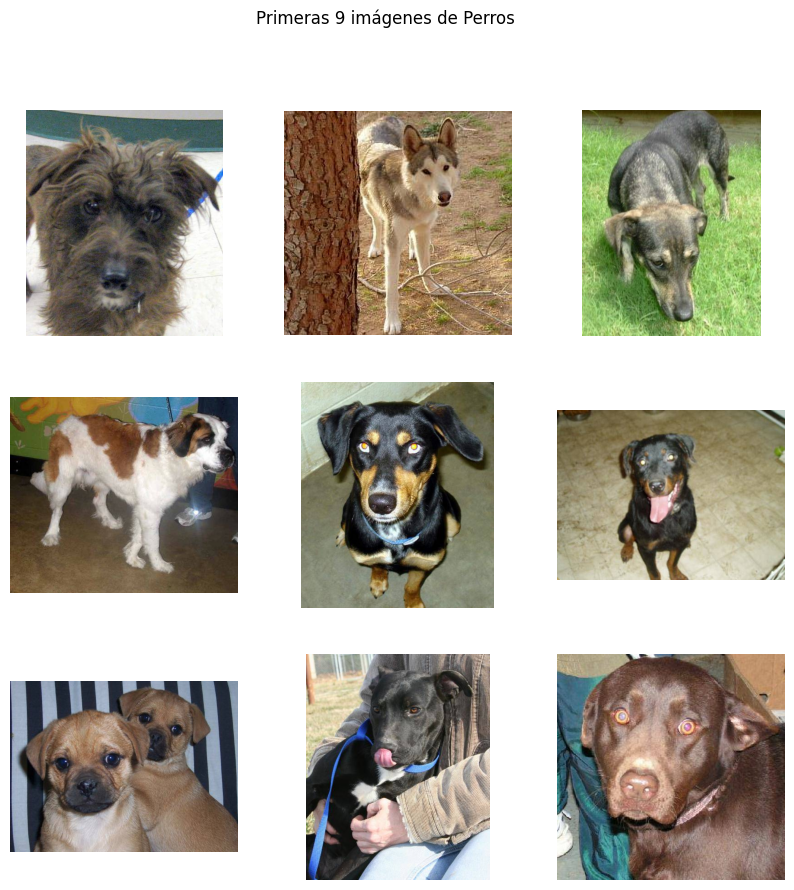

In [34]:

dogs_path = "dataset/train/dog"

dog_images = os.listdir(dogs_path)[:9]

plt.figure(figsize=(10,10))

for i, img_name in enumerate(dog_images):
    img_path = os.path.join(dogs_path, img_name)
    img = image.load_img(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Primeras 9 imágenes de Perros")
plt.show()

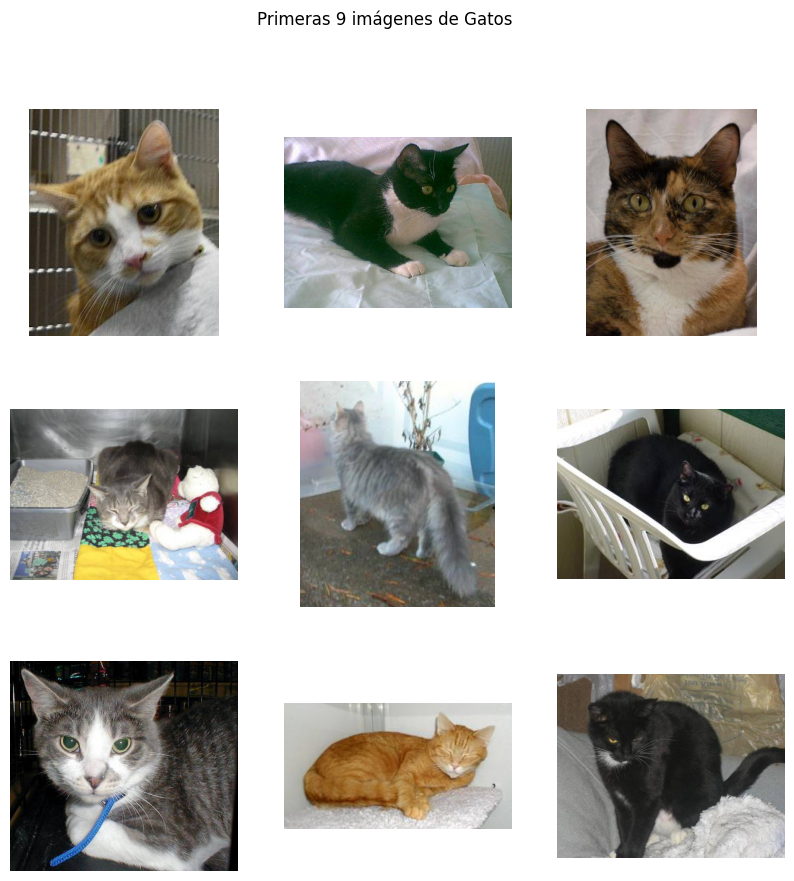

In [35]:
cats_path = "dataset/train/cat"

cat_images = os.listdir(cats_path)[:9]

plt.figure(figsize=(10,10))

for i, img_name in enumerate(cat_images):
    img_path = os.path.join(cats_path, img_name)
    img = image.load_img(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Primeras 9 imágenes de Gatos")
plt.show()

## **3. Construye un RNA**

In [36]:


model = Sequential()

# Bloque 1
model.add(Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(200,200,3)))
model.add(Conv2D(32, (3,3), padding="same", activation="relu"))
model.add(MaxPool2D((2,2)))

# Bloque 2
model.add(Conv2D(64, (3,3), padding="same", activation="relu"))
model.add(Conv2D(64, (3,3), padding="same", activation="relu"))
model.add(MaxPool2D((2,2)))

# Bloque 3
model.add(Conv2D(128, (3,3), padding="same", activation="relu"))
model.add(Conv2D(128, (3,3), padding="same", activation="relu"))
model.add(MaxPool2D((2,2)))

# 👇 CAMBIO CLAVE
model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 200, 200, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,649 (1.16 MB)

 Trainable params: 303,649 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

## **4.  Optimiza el modelo anterior**

In [37]:


checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [38]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    steps_per_epoch=100,
    validation_steps=50,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5027 - loss: 0.6934

100/100 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.5026 - loss: 0.6934 - val_accuracy: 0.4825 - val_loss: 0.6927
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5237 - loss: 0.6891

100/100 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.5237 - loss: 0.6891 - val_accuracy: 0.5075 - val_loss: 0.7162
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4967 - loss: 0.7054

100/100 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.4969 - loss: 0.7054 - val_accuracy: 0.5375 - val_loss: 0.6916
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5340 - loss: 0.6912

100/100 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.5340 - loss: 0.6912 - val_accuracy: 0.5750 - val_loss: 0.6843
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5881 - loss: 0.6849

100/100 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.5879 - loss: 0.6849 - val_accuracy: 0.5900 - val_loss: 0.6717


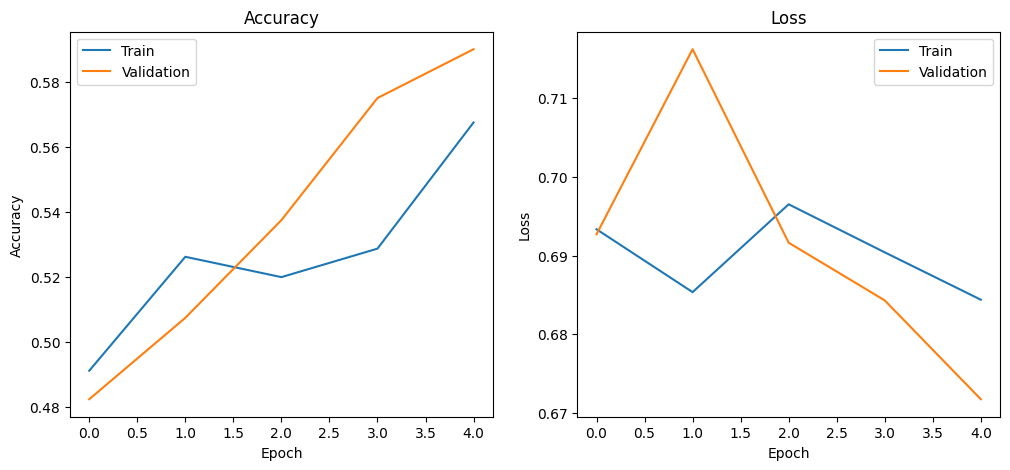

In [39]:


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

In [43]:
checkpoint = ModelCheckpoint(
    "best_model.h5",)

In [44]:
from tensorflow.keras.models import load_model

best_model = load_model("best_model.h5")

In [46]:
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(200,200),
    batch_size=8,
    class_mode='binary',
    shuffle=False
)

Found 5000 images belonging to 2 classes.


In [48]:
test_loss, test_acc = best_model.evaluate(val_generator)

print("Test Accuracy:", test_acc)

625/625 ━━━━━━━━━━━━━━━━━━━━ 345s 552ms/step - accuracy: 0.6527 - loss: 0.6831
Test Accuracy: 0.6015999913215637


In [51]:
predictions = best_model.predict(val_generator)
predicted_classes = (predictions > 0.5).astype(int).ravel()

625/625 ━━━━━━━━━━━━━━━━━━━━ 328s 524ms/step


In [52]:

true_classes = val_generator.classes

print(confusion_matrix(true_classes, predicted_classes))
print(classification_report(true_classes, predicted_classes))

[[1654  851]
 [1141 1354]]
              precision    recall  f1-score   support

           0       0.59      0.66      0.62      2505
           1       0.61      0.54      0.58      2495

    accuracy                           0.60      5000
   macro avg       0.60      0.60      0.60      5000
weighted avg       0.60      0.60      0.60      5000



## **5. Guarda el Modelo**

In [55]:
best_model.save("modelo_final.keras")

In [56]:
files.download("modelo_final.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>